In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import reboundx

## Data
 For the simulation, let's consider the data from an X-ray binary source (M-51)
 
 Star (Blue supergiant)
 
 $M_s=20~M_\odot$, $R_s= 25~R_\odot \approx 0.1163~Au$

 Black Hole (Stellar mass black hole)
 
 $M_{bh}=10~M_\odot$, $R_{bh}= 4.122x10^{-5}~R_\odot \approx 2.005x10^{-7}~Au$

 Planet (Let's consider a Jupyter-like planet)
 
 $M_p=9.5479x10^{-4}~M_\odot$, $R_p= 4.7789x10^{-4}~Au$

 Black hole-Star separation
 
 semi major axis : $a=3 Au$

In [36]:
#function that defines the parameters of the simulation
def make_sim(use_gr=False):
    sim = rb.Simulation()
    sim.units = ('yr', 'AU', 'Msun')
    M_jup = 9.5479e-4           # Msun aprox
    R_jup = 4.7789e-4           # AU aprox
    sim.add(m=20, r=0.1163)                  # star
    sim.add(m=10.0, a=3.0, e=0.2,r=2.005e-7)   # black hole
    sim.add(m=M_jup, r=R_jup, a=0.4, e=0.0, primary=sim.particles[0])  # planet

    sim.move_to_com()
    sim.integrator = "ias15"

    if use_gr:
        rebx = reboundx.Extras(sim)
        gr = rebx.load_force("gr_full")
        rebx.add_force(gr)
        gr.params["c"] = 63239.7263

    return sim
 #This part helps us to simulate the orbits  
def run_sim(sim, tmax, nout=200):
    times = np.linspace(0, tmax, nout)

    x_s, y_s = [], []  #star
    x_bh, y_bh = [], [] #black hole
    x_p, y_p = [], [] #planet

    for t in times:
        sim.integrate(t)

        x_s.append(sim.particles[0].x)
        y_s.append(sim.particles[0].y)

        x_bh.append(sim.particles[1].x)
        y_bh.append(sim.particles[1].y)

        x_p.append(sim.particles[2].x)
        y_p.append(sim.particles[2].y)

    return times, np.array(x_s), np.array(y_s), np.array(x_bh), np.array(y_bh), np.array(x_p), np.array(y_p)
# Time span
a = 3.0
M_total = 20+ 10.0
G = 4*np.pi**2
period = 2*np.pi*np.sqrt(a**3/(G*M_total))
tmax = period

# Run both
'''
Classical Approach
'''
sim_newton = make_sim(use_gr=False)
'''
General Relativity Approach
'''
sim_gr = make_sim(use_gr=True)

tN, x_sN, y_sN, x_bhN, y_bhN, x_pN, y_pN = run_sim(sim_newton, tmax)
tG, x_sG, y_sG, x_bhG, y_bhG, x_pG, y_pG = run_sim(sim_gr, tmax)

# Running the simulation

In [37]:
# Time span
a = 3.0
M_total = 20+ 10.0
G = 4*np.pi**2
period = 2*np.pi*np.sqrt(a**3/(G*M_total))
tmax = period

# Run both
'''
Classical Approach
'''
sim_newton = make_sim(use_gr=False)
'''
General Relativity Approach
'''
sim_gr = make_sim(use_gr=True)

tN, x_sN, y_sN, x_bhN, y_bhN, x_pN, y_pN = run_sim(sim_newton, tmax)
tG, x_sG, y_sG, x_bhG, y_bhG, x_pG, y_pG = run_sim(sim_gr, tmax)

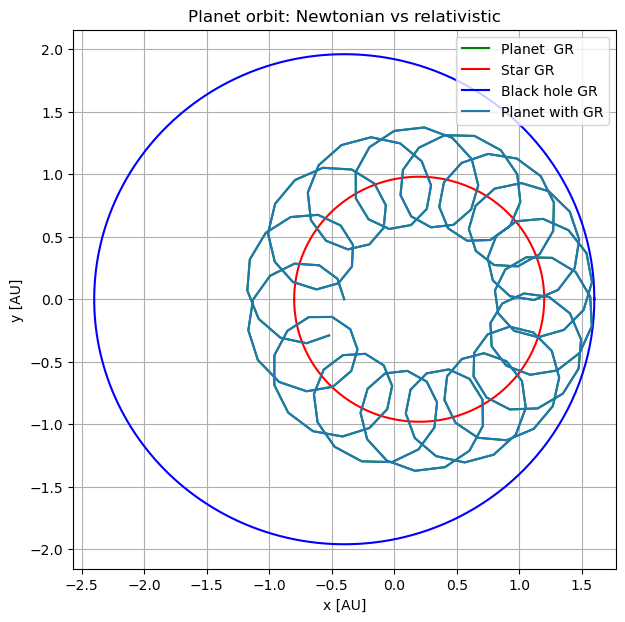

In [38]:
# Plot planet only
plt.figure(figsize=(7,7))
plt.plot(x_pG, y_pG, label="Planet  GR", c='g')
plt.plot(x_sG, y_sG, label="Star GR", c='r')
plt.plot(x_bhG, y_bhG, label="Black hole GR", c='b')
#plt.plot(x_sN, y_sN, label="Star without GR")
#plt.plot(x_bhN, y_bhN, label="Black Hole without GR")
plt.plot(x_pG, y_pG, label="Planet with GR")

#plt.scatter(x_sG, y_sG, color="green", s=10)
#plt.scatter(x_bhG, y_bhG, color="orange", s=20)
#plt.scatter(x_pG, y_pG, color="blue", s=5)
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Planet orbit: Newtonian vs relativistic")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [39]:
# --- PLOT ---
for t in range(len(tG)):
    plt.figure(figsize=(8, 8))
    # Final Positions of the objects (plotted as dots)
    plt.scatter(x_sG[t], y_sG[t], color="green", s=10)
    plt.scatter(x_bhG[t], y_bhG[t], color="orange", s=20)
    plt.scatter(x_pG[t], y_pG[t], color="blue", s=5)
    #plt.scatter(com.x,com.y, color='red',label='cm')
    
    plt.plot(x_sG[0:t+1], y_sG[0:t+1], linestyle = 'dotted',label="star", color="green", lw=3)
    plt.plot(x_bhG[0:t+1], y_bhG[0:t+1], linestyle = '--',label="Black Hole", color="orange")
    plt.plot(x_pG[0:t+1], y_pG[0:t+1], linestyle = '-',label="Planet", color="blue", alpha=0.6)
    
    #plt.axis('equal')
    plt.xlim(-3-0.02,3+0.5)
    plt.ylim(-3-0.02,3+0.02)
    plt.xlabel('Distance~[AU]')
    plt.ylabel('Distance~[AU]')
    plt.title(r"$Restricted ~system: Planet -> star-> black hole$")
    plt.legend()
    plt.savefig("./outputfolder/imgs/orbitorbit{:04d}.png".format(t))
    plt.close()

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import argparse
import os
from shutil import rmtree
import glob
from PIL import Image
import glob
from PIL import Image


In [41]:
images_in = "./outputfolder/imgs/orbit**.png"

gif_image_out = "./outputfolder/imgs/orbit.gif"

imgs = (Image.open(f) for f in sorted(glob.glob(images_in)))

img = next(imgs)

img.save(fp = gif_image_out, format='GIF', append_images=imgs, save_all=True, duration=150, loop=0)

In [42]:
#Importing Libraries:
from IPython.display import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

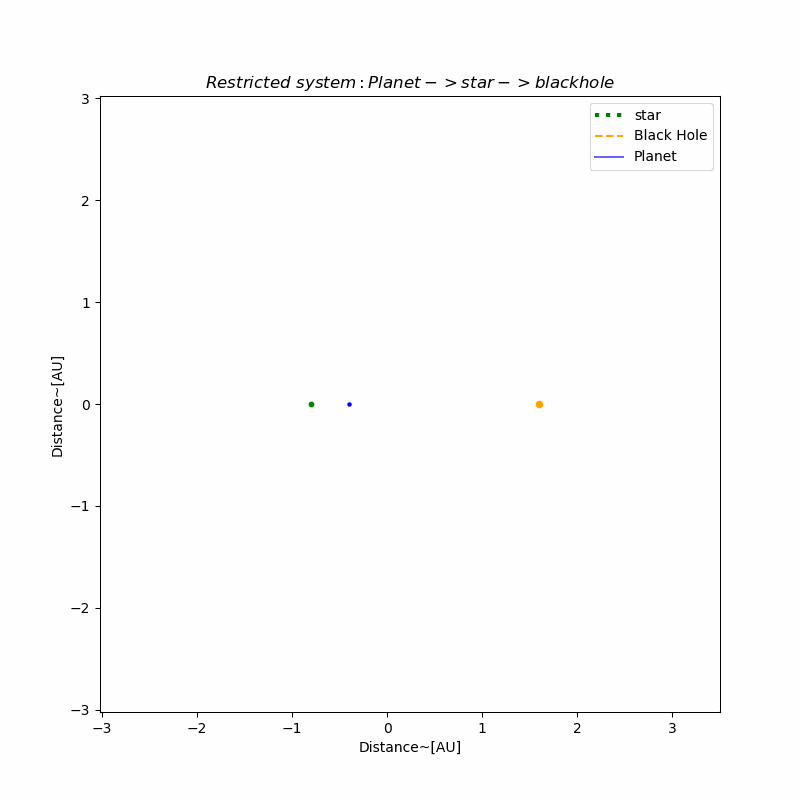

In [43]:
# Displaying the gif 
Image(filename="./outputfolder/imgs/orbit.gif") 

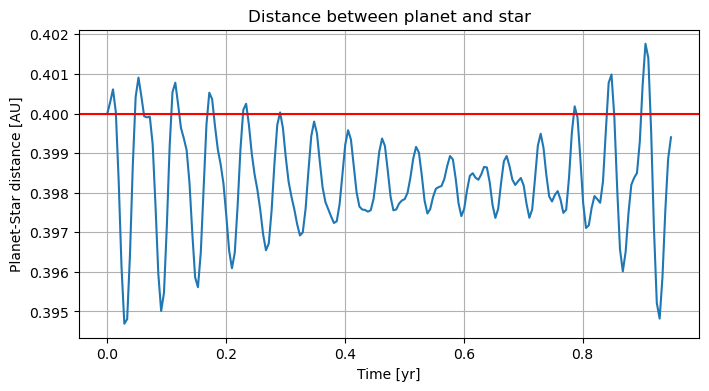

In [46]:
r_ps = np.sqrt((np.array(x_pG) - np.array(x_sG))**2 + (np.array(y_pG) - np.array(y_sG))**2)

plt.figure(figsize=(8,4))
plt.plot(tG, r_ps)
plt.xlabel("Time [yr]")
plt.ylabel("Planet-Star distance [AU]")
plt.title("Distance between planet and star")
plt.axhline(0.4,c='r')
plt.grid(True)
plt.show()

### Stability analysis

In [91]:
#function that defines the parameters of the simulation
def make_sim(a_p,use_gr=False):
    sim = rb.Simulation()
    sim.units = ('yr', 'AU', 'Msun')
    M_jup = 9.5479e-4           # Msun aprox
    R_jup = 4.7789e-4           # AU aprox
    sim.add(m=20, r=0.1163)                  # star
    sim.add(m=10.0, a=3.0, e=0.2,r=2.005e-7)   # black hole
    sim.add(m=M_jup, r=R_jup, a=a_p, e=0.0, primary=sim.particles[0])  # planet

    sim.move_to_com()
    sim.integrator = "ias15"

    if use_gr:
        rebx = reboundx.Extras(sim)
        gr = rebx.load_force("gr_full")
        rebx.add_force(gr)
        gr.params["c"] = 63239.7263

    return sim
 #This part helps us to simulate the orbits  
def run_sim(sim, nout=10000):
    a=sim.particles[1].a
    M_total = sim.particles[0].m + sim.particles[1].m
    period = 2*np.pi*np.sqrt(a**3/(sim.G*M_total))
    tmax = period
    times = np.linspace(0, 0.25*tmax, nout)
    x_s, y_s ,z_s= [], [] ,[] #star
    x_bh, y_bh ,z_bh= [], [],[] #black hole
    x_p, y_p ,z_p= [], [] ,[]#planet
    print('Period:',tmax, '~yrs')
    for t in times:
        sim.integrate(t)

        x_s.append(sim.particles[0].x)
        y_s.append(sim.particles[0].y)
        z_s.append(sim.particles[0].z)
        
        x_bh.append(sim.particles[1].x)
        y_bh.append(sim.particles[1].y)
        z_bh.append(sim.particles[1].z)
        
        x_p.append(sim.particles[2].x)
        y_p.append(sim.particles[2].y)
        z_p.append(sim.particles[2].z)
    r_pro= np.sqrt((np.array(y_p) - np.array(y_s))**2 + (np.array(z_p) - np.array(z_s))**2)
    '''
    Projected Distance
    '''
    r_ps= np.sqrt((np.array(x_p) - np.array(x_s))**2 + (np.array(y_p) - np.array(y_s))**2)

    return times, np.array(x_s), np.array(y_s), np.array(x_bh), np.array(y_bh), np.array(x_p), np.array(y_p),r_ps,r_pro




In [92]:
'''
General Relativity Approach
'''
aps=[0.1,0.2,0.3,0.4,0.5,0.6]
sims=[]
for i in range(len(aps)):
    sims.append(make_sim(aps[i],use_gr=True))



In [93]:
planet_1=run_sim(sims[0])
planet_2=run_sim(sims[1])
planet_3=run_sim(sims[2])
planet_4=run_sim(sims[3])
planet_5=run_sim(sims[4])
planet_6=run_sim(sims[5])

Period: 0.9487012154412653 ~yrs
Period: 0.9487012154412653 ~yrs
Period: 0.9487012154412653 ~yrs
Period: 0.9487012154412653 ~yrs
Period: 0.9487012154412653 ~yrs
Period: 0.9487012154412653 ~yrs


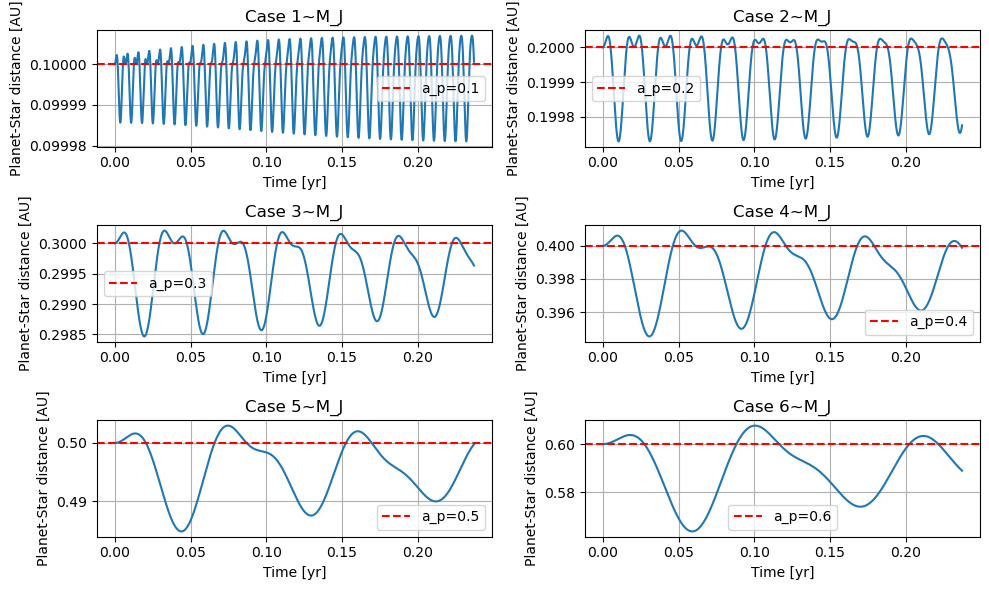

In [94]:
fig, axes = plt.subplots(3, 2, figsize=(10, 6))

datasets = [planet_1, planet_2, planet_3, planet_4, planet_5, planet_6]
titles = ["Case 1~M_J", "Case 2~M_J", "Case 3~M_J", "Case 4~M_J", "Case 5~M_J", "Case 6~M_J" ]
h_lines = [0.1, 0.2, 0.3, 0.4,0.5, 0.6]

for ax, data, title, h in zip(axes.flatten(), datasets, titles, h_lines):
    
    ax.plot(data[0], data[7])
    
    ax.set_xlabel("Time [yr]")
    ax.set_ylabel("Planet-Star distance [AU]")
    ax.set_title(title)
    
    ax.axhline(y=h, c='r', linestyle='--', label=f'a_p={h}')
    ax.legend()
    
    ax.grid(True)

plt.tight_layout()
plt.show()

Since I am considering 12 periods (11 years). The system remains stable

### Transit Simulation

In [105]:
times=planet_3[0] # zero corresponds to time
R_p=4.7789e-4 #AU
R_star=0.1163 #AU
flux = np.ones(len(times))
for i, t in enumerate(times):
    if planet_3[8][i]<(R_p+R_star):
        flux[i] -= (R_p/R_star)**2
    

In [141]:
def flux(data):
    times = data[0]
    R_p = 4.7789e-4
    R_star = 0.1163
    
    fluxs = np.ones(len(times))
    
    for i in range(len(times)):
        if data[8][i] < (R_p + R_star):
            fluxs[i] -= (R_p / R_star)**2
            
    return times, fluxs
    

In [142]:
planets=[planet_1, planet_2, planet_3, planet_4, planet_5, planet_6]
fluxes=[]
for i in range(6):
    fluxes.append(flux(planets[i])[1])

In [143]:
np.shape(fluxes)

(6, 10000)

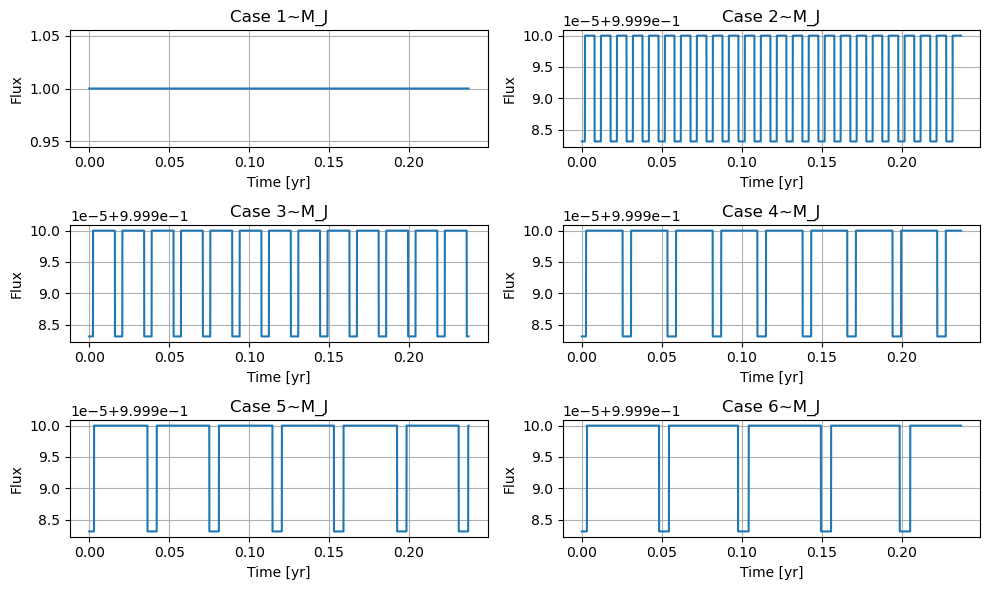

In [145]:
fig, axes = plt.subplots(3, 2, figsize=(10, 6))

datasets = fluxes
titles = ["Case 1~M_J", "Case 2~M_J", "Case 3~M_J", "Case 4~M_J", "Case 5~M_J", "Case 6~M_J" ]
#h_lines = [0.1, 0.2, 0.3, 0.4,0.5, 0.6]

for ax, data, title in zip(axes.flatten(), datasets, titles):
    
    ax.plot(planet_1[0], data)
    
    ax.set_xlabel("Time [yr]")
    ax.set_ylabel("Flux")
    ax.set_title(title)
    
   # ax.legend()
    
    ax.grid(True)
#plt.ylim(np.min(data)-1e-6, 1.00001)
plt.tight_layout()
plt.show()